In [1]:
!pip install pandas numpy matplotlib scikit-learn joblib


In [6]:
import pandas as pd

df = pd.read_csv(
    "Sample - Superstore.csv",
    encoding="latin1"
)

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [7]:
df.shape

(9994, 21)

In [8]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

In [9]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [10]:
df = df.dropna()

In [11]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [12]:
df["Order Date"] = pd.to_datetime(
    df["Order Date"]
)

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   object        
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object        
 15  Sub-Category   9994 n

In [14]:
df["Year"] = df["Order Date"].dt.year

df["Month"] = df["Order Date"].dt.month

df["Day"] = df["Order Date"].dt.day

df["Weekday"] = df["Order Date"].dt.weekday


df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Year,Month,Day,Weekday
0,1,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2016,11,8,1
1,2,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2016,11,8,1
2,3,CA-2016-138688,2016-06-12,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2016,6,12,6
3,4,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015,10,11,6
4,5,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2015,10,11,6


In [15]:
import matplotlib.pyplot as plt

In [16]:
sales_trend = df.groupby(
    "Order Date"
)["Sales"].sum()

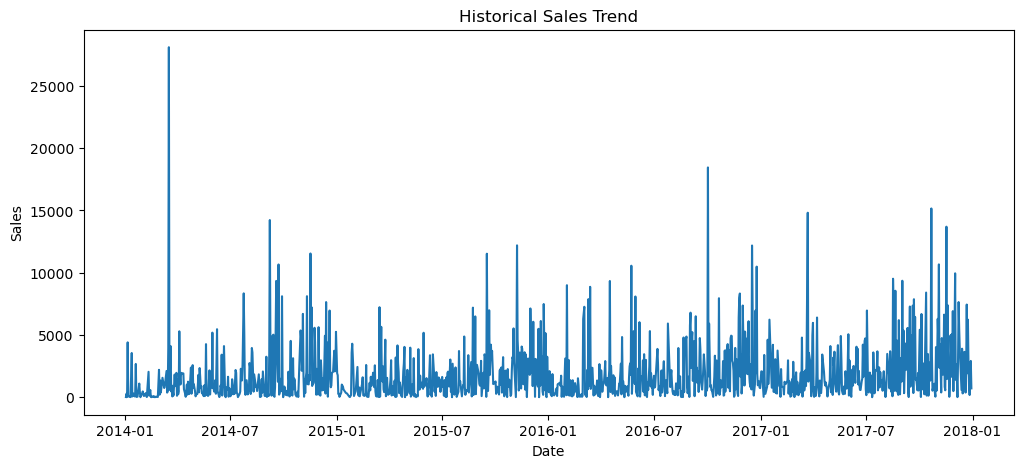

In [17]:
plt.figure(figsize=(12,5))

plt.plot(
    sales_trend.index,
    sales_trend.values
)

plt.title(
    "Historical Sales Trend"
)

plt.xlabel(
    "Date"
)

plt.ylabel(
    "Sales"
)

plt.show()

In [18]:
import numpy as np

df["Trend"] = np.arange(
    len(df)
)

In [19]:
X = df[
[
"Trend",
"Year",
"Month",
"Day",
"Weekday"
]
]

In [20]:
y = df["Sales"]

In [21]:
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,
    test_size=0.2,
    shuffle=False

)

In [22]:
from sklearn.linear_model import LinearRegression


model = LinearRegression()


model.fit(
    X_train,
    y_train
)

LinearRegression()

In [23]:
prediction = model.predict(
    X_test
)

prediction[:5]

array([238.15541184, 214.66400569, 214.66377734, 235.39297776,
       235.39274941])

In [24]:
from sklearn.metrics import mean_absolute_error, mean_squared_error


mae = mean_absolute_error(
    y_test,
    prediction
)


rmse = np.sqrt(
    mean_squared_error(
        y_test,
        prediction
    )
)


print("MAE:",mae)

print("RMSE:",rmse)

MAE: 268.89333282435393
RMSE: 632.599380093872


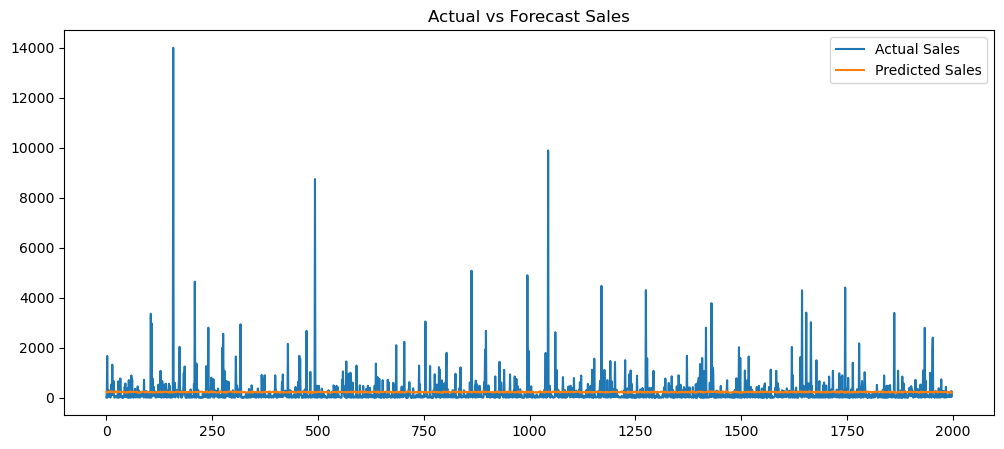

In [25]:
plt.figure(figsize=(12,5))


plt.plot(
    y_test.values,
    label="Actual Sales"
)


plt.plot(
    prediction,
    label="Predicted Sales"
)


plt.title(
"Actual vs Forecast Sales"
)


plt.legend()

plt.show()

In [26]:
future_date = pd.to_datetime(
    "2026-01-01"
)


future = pd.DataFrame({

"Trend":[len(df)],

"Year":[future_date.year],

"Month":[future_date.month],

"Day":[future_date.day],

"Weekday":[future_date.weekday()]

})


future

,Trend,Year,Month,Day,Weekday
0,9994,2026,1,1,3


In [27]:
future_sales = model.predict(
    future
)


print(
"Forecasted Sales:",
future_sales[0]
)

Forecasted Sales: 114.56694139725005


In [28]:
!pip install joblib

In [29]:
import joblib


joblib.dump(
    model,
    "sales_forecast_model.pkl"
)

['sales_forecast_model.pkl']